<img src="https://raw.githubusercontent.com/iamYannC/Ebbinghaus/main/docs/hex.png" alt="Ebbinghaus hex logo" align="right" width="15%" height="auto"/>

The **Ebbinghaus Illusion Benchmark** is designed to evaluate both VLMs and human participants on variants of the Ebbinghaus illusion.

This notebook is a Kaggle implementation of the original project, comparing [Gemma 3 4B](https://huggingface.co/google/gemma-3-4b-it) and [Qwen2-VL 2B](https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct) via [Hugging Face](https://huggingface.co/) (requires an API key) on Kaggle's free GPU runtime. The pipeline is identical to the original, with minor adaptations for this environment.

The full code (R and Python) and technical reference are available at [`iamYannC/Ebbinghaus`](https://github.com/iamYannC/Ebbinghaus).

_© [Yann Cohen](https://orcid.org/0009-0009-0509-3609) 2026 - CC BY 4.0 - [doi](https://doi.org/10.5281/zenodo.18906801)_
___


# Preparations

## Imports
All Python dependencies used by this notebook.

In [ ]:
!pip install -q bitsandbytes>=0.46.1 qwen-vl-utils

import os
import sys
import time
from datetime import datetime, timezone

import pandas as pd
import torch
from PIL import Image
from transformers import AutoProcessor, BitsAndBytesConfig
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

In [ ]:
# Auth
hf_token = UserSecretsClient().get_secret("HF_TOKEN")
login(token=hf_token)

# Device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

## Setup
Configure filesystem paths, create output directories, and authenticate with Hugging Face.

This step requires a (free) Hugging Face API key and registering it as a secret on Kaggle.

**DO NOT hardcode the key in this notebook!**

In [19]:
ROOT        = "/kaggle/input/datasets/yanncohen/ebbinghaus-illusion-benchmark"
WORK        = "/kaggle/working"
IMAGES      = os.path.join(WORK, "output", "images")
IMAGES_EVAL = os.path.join(WORK, "output", "images_eval")
PLOTS       = os.path.join(WORK, "output", "plots")
TRIALS_CSV  = os.path.join(WORK, "output", "trials.csv")

os.makedirs(IMAGES,      exist_ok=True)
os.makedirs(IMAGES_EVAL, exist_ok=True)
os.makedirs(PLOTS,       exist_ok=True)

# Project imports
sys.path.insert(0, os.path.join(ROOT, "py"))
from src.generate_design import generate_design
from src.render_stimuli import render_stimuli
from src.strip_answer import strip_answer_from_images
from src.evaluate import fill_prompt, parse_response

# Phase 1

## Generate Data
Build a design matrix, render stimulus images, and load prompt templates.

## Prepare Evaluation Images
Copy stimulus images with ground-truth info stripped from filenames, so the model can't cheat.

In [ ]:
trials = generate_design(seed=42, n_per_tier=10, image_dir=IMAGES)
render_stimuli(trials)
trials.to_csv(TRIALS_CSV, index=False)
trials = strip_answer_from_images(trials, output_dir=IMAGES_EVAL)

prompts = pd.read_csv(os.path.join(ROOT, "data", "prompts.csv")).head(2)

print(f"{len(trials)} trials, {len(prompts)} prompts")
trials[["trial_id", "tier", "orientation", "true_larger"]]

# Phase 2

## Model Configs, Loader & Input Builder
Each model has a different chat template and processor call signature.
The `build_inputs()` adapter normalises this.

In [3]:
MODEL_CONFIGS = [
    {
        "label":       "gemma-3-4b-it",
        "provider":    "google",
        "model_id":    "google/gemma-3-4b-it",
        "model_class": "Gemma3ForConditionalGeneration",
    },
    {
        "label":       "qwen2-vl-2b-instruct",
        "provider":    "alibaba",
        "model_id":    "Qwen/Qwen2-VL-2B-Instruct",
        "model_class": "Qwen2VLForConditionalGeneration",
    },
]


def load_model(cfg, device):
    quant_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16)
    kwargs = {
        "device_map":          device,
        "quantization_config": quant_config,
        "attn_implementation": "eager",
    }
    processor = AutoProcessor.from_pretrained(cfg["model_id"])
    if cfg["model_class"] == "Qwen2VLForConditionalGeneration":
        from transformers import Qwen2VLForConditionalGeneration
        model = Qwen2VLForConditionalGeneration.from_pretrained(cfg["model_id"], **kwargs)
    elif cfg["model_class"] == "Gemma3ForConditionalGeneration":
        from transformers import Gemma3ForConditionalGeneration
        model = Gemma3ForConditionalGeneration.from_pretrained(cfg["model_id"], **kwargs)
    else:
        raise ValueError(f"Unknown model_class: {cfg['model_class']}")
    return model, processor


def build_inputs(cfg, processor, model, image, text):
    """Normalise processor call across model families."""
    if cfg["model_class"] == "Qwen2VLForConditionalGeneration":
        from qwen_vl_utils import process_vision_info
        messages = [{"role": "user", "content": [
            {"type": "image", "image": image},
            {"type": "text",  "text": text},
        ]}]
        prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        image_inputs, video_inputs = process_vision_info(messages)
        inputs = processor(
            text=[prompt], images=image_inputs, videos=video_inputs,
            return_tensors="pt", padding=True,
        ).to(model.device)
    else:  # Gemma3
        messages = [{"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": text},
        ]}]
        prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
        inputs = processor(images=image, text=prompt, return_tensors="pt").to(model.device)
    return inputs

## Run Evaluation
Loop over every (model × prompt × trial) combination: build a chat message with the stimulus image, generate a response, parse the answer, and record the result.

In [ ]:
results = []

for cfg in MODEL_CONFIGS:
    print(f"\n{'='*60}\nLoading {cfg['label']}...\n{'='*60}")
    model, processor = load_model(cfg, DEVICE)

    for _, prompt_row in prompts.iterrows():
        for _, row in trials.iterrows():
            trial    = row.to_dict()
            raw_text = fill_prompt(prompt_row["user_prompt_template"], trial)
            image    = Image.open(row["file_path"])
            inputs   = build_inputs(cfg, processor, model, image, raw_text)

            t0 = time.time()
            with torch.no_grad():
                output = model.generate(**inputs, max_new_tokens=50)
            latency_ms = round((time.time() - t0) * 1000)

            input_len = inputs["input_ids"].shape[-1]
            response  = processor.decode(
                output[0][input_len:], skip_special_tokens=True
            ).strip().lower()
            parsed = parse_response(response, row["orientation"], prompt_row["response_format"])

            results.append({
                "eval_id":             len(results) + 1,
                "trial_id":            row["trial_id"],
                "prompt_id":           prompt_row["prompt_id"],
                "provider":            cfg["provider"],
                "model":               cfg["label"],
                "model_version":       None,
                "temperature":         0,
                "max_tokens":          50,
                "response_larger":     parsed,
                "response_confidence": None,
                "raw_response":        response,
                "latency_ms":          latency_ms,
                "timestamp":           datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
                "error":               None,
            })

    # Free VRAM before loading next model
    del model, processor
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    import gc; gc.collect()
    print("  Done. VRAM freed.")

print(f"\nTotal evals: {len(results)}")

## Save & Summarize

In [ ]:
evals = pd.DataFrame(results)
print(f"{len(evals)} evals recorded")
evals.groupby(["model", "prompt_id"])["response_larger"].value_counts()

# Phase 3
## Analyze Results
Analysis: join evals with trial/prompt metadata, compute accuracy and bias metrics, and display all diagnostic plots inline.

This is somewhat of an optional phase. You are encouraged to come up with your own plots and analysis!

Analysis complete. Metrics available in results['metrics']. Plots available in results['plots'].


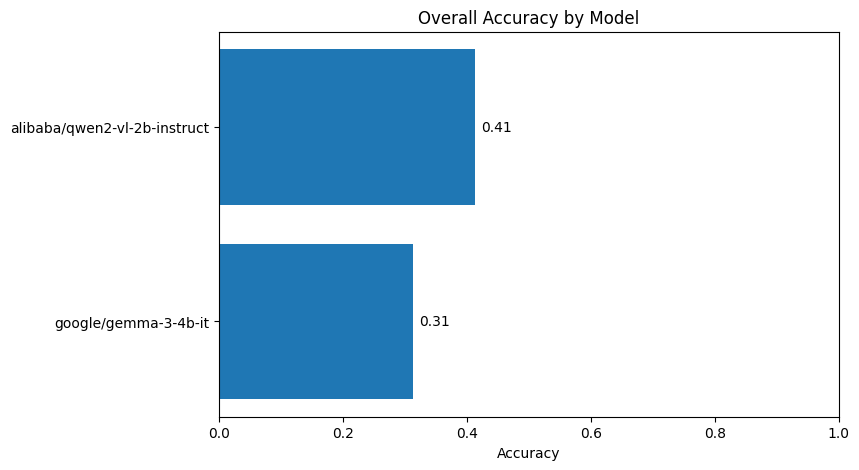

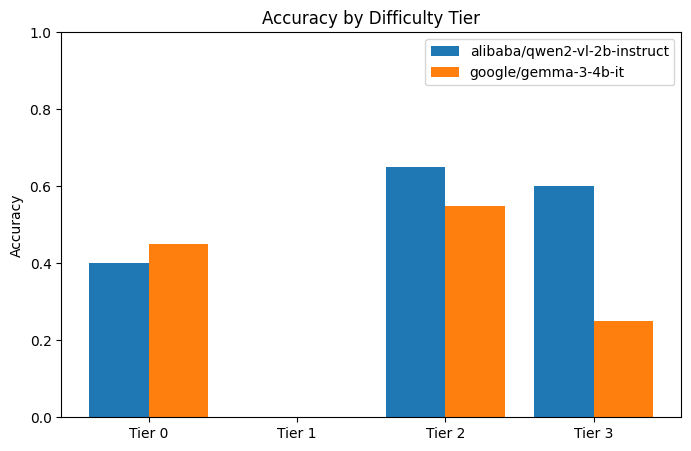

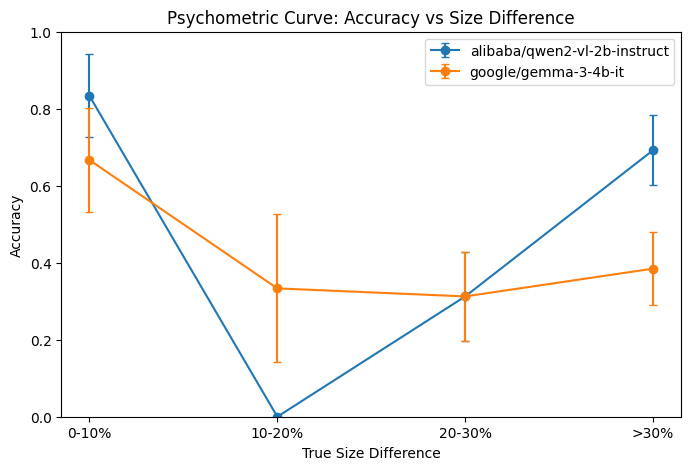

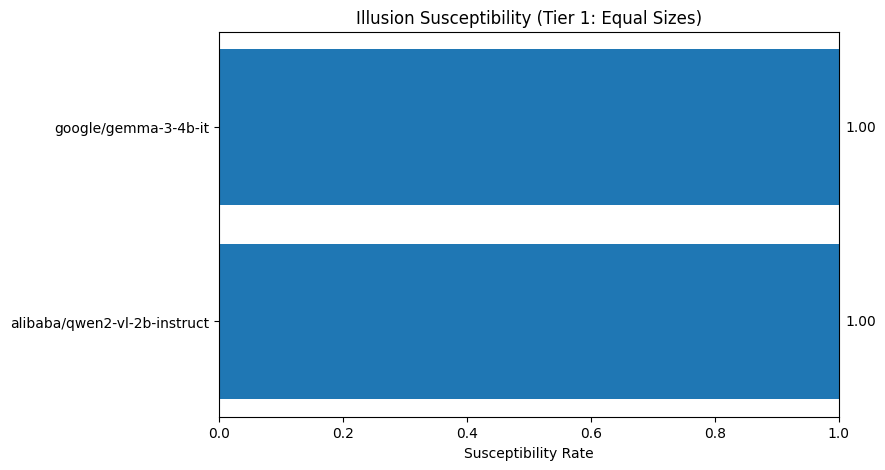

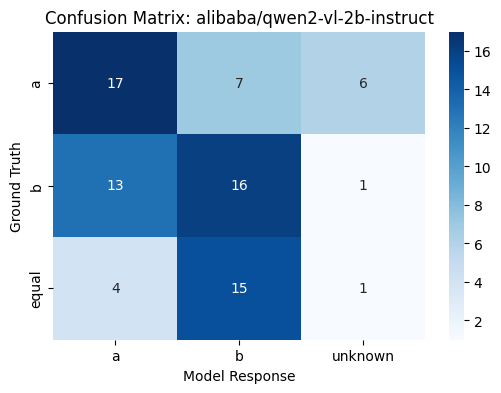

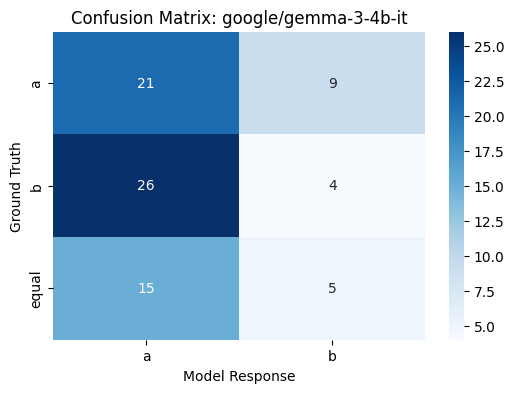

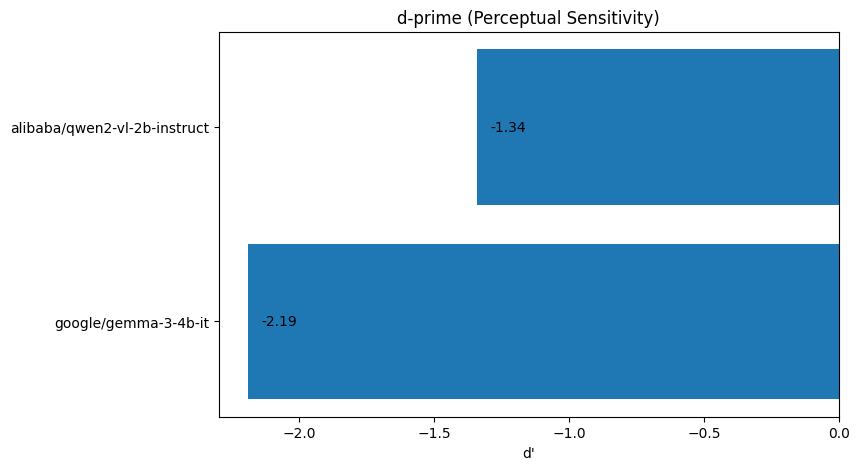

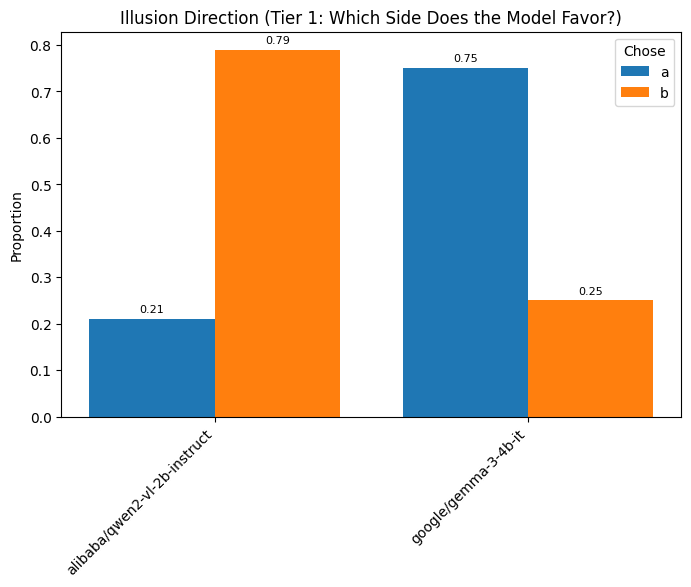

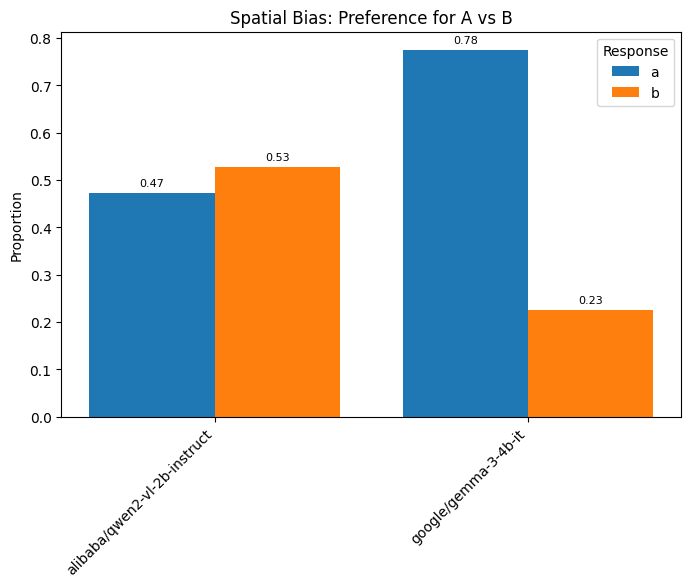

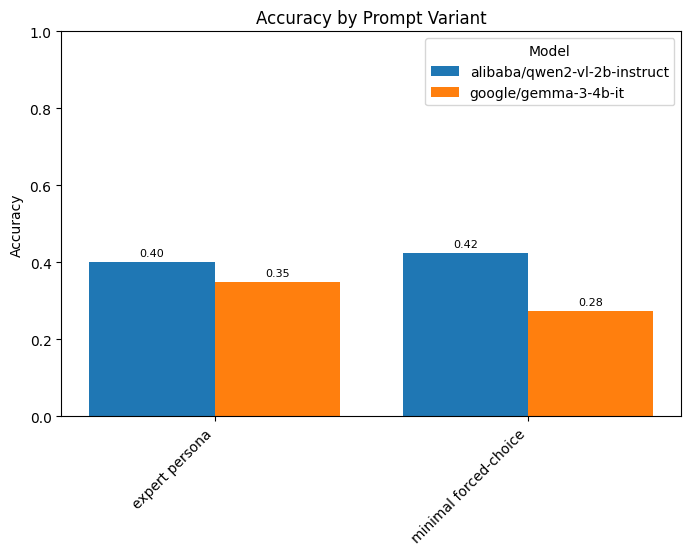

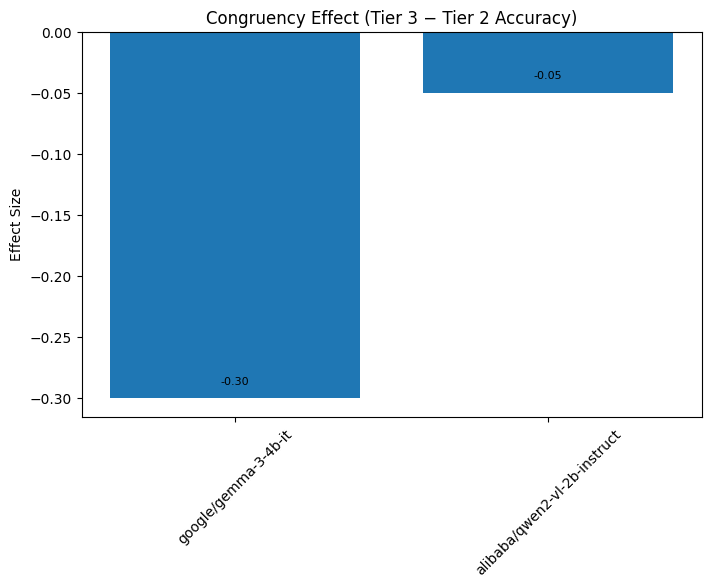

In [21]:
from src.analyze import analyze_results
results = analyze_results(
    evals_df=evals,
    trials_path=TRIALS_CSV,
    prompts_path=f"{ROOT}/data/prompts.csv",
    output_dir=PLOTS,
)